STEP1: Import and Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/adult_income.csv')

print("Shape:", df.shape)
print("\nExact Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (48842, 15)

Exact Columns: ['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

First 5 rows:
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv  

STEP 2: CLEAN THE DATA

In [5]:
df = df.replace('?', np.nan)
df = df.dropna()

# Using exact column names from your file
df = df[['age', 'occupation', 'hours-per-week', 'income']]

df['income_level'] = df['income'].apply(lambda x: 1 if '>50K' in x else 0)

print("Shape after cleaning:", df.shape)
print("\nIncome distribution:")
print(df['income_level'].value_counts())

Shape after cleaning: (45222, 5)

Income distribution:
income_level
0    34014
1    11208
Name: count, dtype: int64


STEP 3: SIMULATE MONTHLY INCOME

In [6]:
np.random.seed(42)

def simulate_income(row):
    if row['income_level'] == 1:  # >50K annually
        return np.random.randint(50000, 150000) // 12
    else:
        return np.random.randint(15000, 50000) // 12

df['monthly_income'] = df.apply(simulate_income, axis=1)

print("Monthly income stats:")
print(df['monthly_income'].describe())

Monthly income stats:
count    45222.000000
mean      4092.667374
std       2796.956742
min       1250.000000
25%       2223.000000
50%       3174.000000
75%       4158.000000
max      12499.000000
Name: monthly_income, dtype: float64


STEP 4: SIMULATE EXPENSE COLUMNS

In [8]:
np.random.seed(42)

df['rent']          = (df['monthly_income'] * np.random.uniform(0.15, 0.35, len(df))).astype(int)
df['food']          = (df['monthly_income'] * np.random.uniform(0.10, 0.25, len(df))).astype(int)
df['emi']           = (df['monthly_income'] * np.random.uniform(0.00, 0.30, len(df))).astype(int)
df['transport']     = (df['monthly_income'] * np.random.uniform(0.03, 0.10, len(df))).astype(int)
df['subscriptions'] = (df['monthly_income'] * np.random.uniform(0.01, 0.05, len(df))).astype(int)
df['savings']       = (df['monthly_income'] * np.random.uniform(0.00, 0.40, len(df))).astype(int)
df['emergency_fund_months'] = np.random.randint(0, 12, len(df))
df['dependents']    = np.random.randint(0, 5, len(df))

print("Sample expense data:")
print(df[['monthly_income','rent','food','emi','savings']].head(10))

Sample expense data:
    monthly_income  rent  food   emi  savings
0             2566   577   472   126      180
1             1321   449   251   152      423
2            10568  3132  2297  2700     1243
3             8740  2357   980  2577     1556
5             1772   321   366   396      146
7            11032  1998  1376    18     4107
8             3080   497   650   834      147
9             2585   835   313    20      744
10            7590  2050  1706  2042     2660
11            1390   405   280   171      362


STEP 5: FEATURE ENGINEERING

In [9]:
df['savings_rate']        = df['savings'] / df['monthly_income']
df['emi_ratio']           = df['emi'] / df['monthly_income']
df['rent_ratio']          = df['rent'] / df['monthly_income']
df['food_ratio']          = df['food'] / df['monthly_income']
df['need_ratio']          = (df['rent'] + df['food'] + df['transport']) / df['monthly_income']
df['want_ratio']          = df['subscriptions'] / df['monthly_income']
df['total_expense_ratio'] = (df['rent'] + df['food'] + df['emi'] +
                              df['transport'] + df['subscriptions']) / df['monthly_income']
df['disposable_ratio']    = 1 - df['total_expense_ratio']

print("Feature stats:")
print(df[['savings_rate','emi_ratio','need_ratio','disposable_ratio']].describe())

Feature stats:
       savings_rate     emi_ratio    need_ratio  disposable_ratio
count  45222.000000  45222.000000  45222.000000      45222.000000
mean       0.200456      0.149478      0.489579          0.331094
std        0.115524      0.086693      0.074471          0.114540
min        0.000000      0.000000      0.282138         -0.007742
25%        0.100843      0.073937      0.435817          0.248523
50%        0.200313      0.149612      0.489865          0.331536
75%        0.300148      0.224430      0.543820          0.413693
max        0.399909      0.299971      0.689787          0.669855


STEP 6: LABEL THE DATA

In [10]:
def label_financial_health(row):
    score = 100

    if row['emi_ratio'] > 0.20:
        score -= 30
    elif row['emi_ratio'] > 0.10:
        score -= 15

    if row['savings_rate'] < 0.10:
        score -= 25
    elif row['savings_rate'] < 0.20:
        score -= 10

    if row['need_ratio'] > 0.60:
        score -= 20
    elif row['need_ratio'] > 0.50:
        score -= 10

    if row['emergency_fund_months'] < 1:
        score -= 15
    elif row['emergency_fund_months'] < 3:
        score -= 5

    if row['dependents'] > 2 and row['disposable_ratio'] < 0.20:
        score -= 10

    if score >= 70:
        return 'Stable'
    elif score >= 45:
        return 'At Risk'
    else:
        return 'Critical'

df['health_label'] = df.apply(label_financial_health, axis=1)

print("Health label distribution:")
print(df['health_label'].value_counts())

Health label distribution:
health_label
Stable      24810
At Risk     16720
Critical     3692
Name: count, dtype: int64


STEP 7: VISUALIZE CLASS DISTRIBUTION

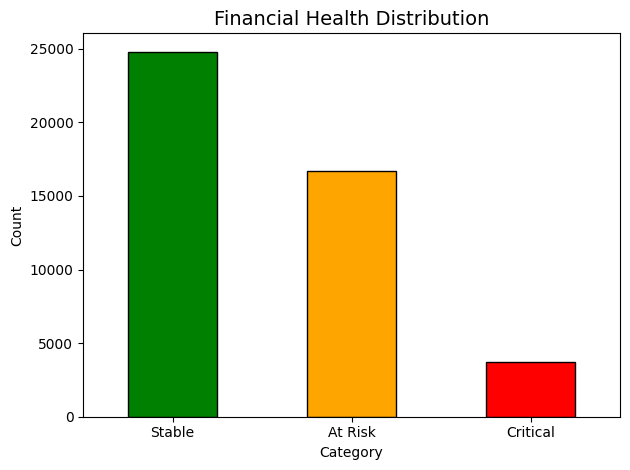

Chart saved to data/processed/


In [11]:
counts = df['health_label'].value_counts()
colors = ['green', 'orange', 'red']

counts.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Financial Health Distribution', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/health_distribution.png')
plt.show()

print("Chart saved to data/processed/")

STEP 8: SAVE PROCESSED DATA(both versions)

In [16]:
feature_cols = [
    'monthly_income', 'savings_rate', 'emi_ratio', 'rent_ratio',
    'food_ratio', 'need_ratio', 'want_ratio', 'total_expense_ratio',
    'disposable_ratio', 'emergency_fund_months', 'dependents', 'health_label'
]

df_processed = df[feature_cols]
df_processed.to_csv('../data/processed/finance_processed.csv', index=False)

print(f"Saved {len(df_processed)} rows")
print("\nSample:")
print(df_processed.head())

Saved 45222 rows

Sample:
   monthly_income  savings_rate  emi_ratio  rent_ratio  food_ratio  \
0            2566      0.070148   0.049104    0.224864    0.183944   
1            1321      0.320212   0.115064    0.339894    0.190008   
2           10568      0.117619   0.255488    0.296366    0.217354   
3            8740      0.178032   0.294851    0.269680    0.112128   
5            1772      0.082393   0.223476    0.181151    0.206546   

   need_ratio  want_ratio  total_expense_ratio  disposable_ratio  \
0    0.461808    0.047545             0.558457          0.441543   
1    0.567752    0.038607             0.721423          0.278577   
2    0.611185    0.027914             0.894587          0.105413   
3    0.427918    0.011327             0.734096          0.265904   
5    0.482506    0.044582             0.750564          0.249436   

   emergency_fund_months  dependents health_label  
0                      5           4       Stable  
1                      9           0    

STEP 9: CREATE utils/feature_engineering.py

In [17]:
code = '''def engineer_features(income, rent, food, emi, transport,
                      subscriptions, savings, emergency_fund, dependents):

    features = {}

    features["monthly_income"]        = income
    features["savings_rate"]          = savings / income
    features["emi_ratio"]             = emi / income
    features["rent_ratio"]            = rent / income
    features["food_ratio"]            = food / income
    features["need_ratio"]            = (rent + food + transport) / income
    features["want_ratio"]            = subscriptions / income
    features["total_expense_ratio"]   = (rent + food + emi + transport + subscriptions) / income
    features["disposable_ratio"]      = 1 - features["total_expense_ratio"]
    features["emergency_fund_months"] = emergency_fund
    features["dependents"]            = dependents

    return features
'''

with open('../utils/feature_engineering.py', 'w') as f:
    f.write(code)

print("feature_engineering.py created in utils/ folder!")

feature_engineering.py created in utils/ folder!
